In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from wassa_functions import performance_as_a_function_of_dataset_parameters
from wassa_training import get_training_parameters
date = '2025-10-15'
device = 'cpu'

In [3]:
dataset_parameters = {
    'seed' : 666,
    
    'N_pre' : 260, # number of neurons
    'N_timesteps' : 250, # number of timesteps for the raster plot (in ms)
    'N_samples' : 30, # total number of samples in the dataset
    'N_sms' : 1, # number of structured spiking motifs

    'temporal_jitter' : 0, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : 0, # percentage of background noise/spontaneous activity
    'min_warping_coef' : 1, # coefficient for time warping
}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_sms'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'proba_sms' : torch.ones(dataset_parameters['N_sms'])/dataset_parameters['N_sms']}) # probability of apparition of the different spiking motif

In [4]:
training_parameters_emd = {
    'kernel_size' : (dataset_parameters['N_sms'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : True,
    'N_learnsteps' : 2000,
    'learning_rate' : .1,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [5]:
training_parameters_mse = {
    'kernel_size' : (dataset_parameters['N_sms'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [6]:
training_metrics = ['training loss', 'testing loss', 'explained variance']
synthetic_metrics = ['kernels similarity', 'mean timings similarity', 'mse', 'emd', 'emd mean timings', 'mean time diff']
n_iter = 100
kfold = 1
do_seqnmf = False

In [7]:
dataset_variables = {
'temporal_jitter' : torch.linspace(0,40,10).tolist(),
}
coefs_jitter = [round(i*100/dataset_parameters['N_timesteps'],1) for i in dataset_variables['temporal_jitter']]
file_name = '../simulations/results_jitter_last'+get_training_parameters(training_parameters_emd)+get_training_parameters(training_parameters_mse)
results_jitter, _ = performance_as_a_function_of_dataset_parameters(file_name, dataset_parameters, training_parameters_emd, training_parameters_mse, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)

0it [00:00, ?it/s]

In [8]:
dataset_variables = {
'min_warping_coef' : torch.linspace(.2,1,10).tolist(),
}
coefs_warping = [(i-.2)*100 for i in dataset_variables['min_warping_coef'][::-1]]
file_name = '../simulations/results_warping_last'+get_training_parameters(training_parameters_emd)+get_training_parameters(training_parameters_mse)
results_warping, _ = performance_as_a_function_of_dataset_parameters(file_name, dataset_parameters, training_parameters_emd, training_parameters_mse, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)

0it [00:00, ?it/s]

In [9]:
dataset_variables = {
'additive_noise' : torch.linspace(0,.9,10).tolist(),
}
coefs_additive = [i*100 for i in dataset_variables['additive_noise']]
file_name = '../simulations/results_additive_last'+get_training_parameters(training_parameters_emd)+get_training_parameters(training_parameters_mse)
results_additive, _ = performance_as_a_function_of_dataset_parameters(file_name, dataset_parameters, training_parameters_emd, training_parameters_mse, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)

0it [00:00, ?it/s]

In [10]:
dataset_variables = {
'dropout_proba' : torch.linspace(0,.9,10).tolist(),
}
coefs_dropout = [dataset_variables['dropout_proba'][i]*100 for i in range(len(dataset_variables['dropout_proba']))]
file_name = '../simulations/results_dropout'+get_training_parameters(training_parameters_emd)+get_training_parameters(training_parameters_mse)
results_dropout, _ = performance_as_a_function_of_dataset_parameters(file_name, dataset_parameters, training_parameters_emd, training_parameters_mse, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)

0it [00:00, ?it/s]

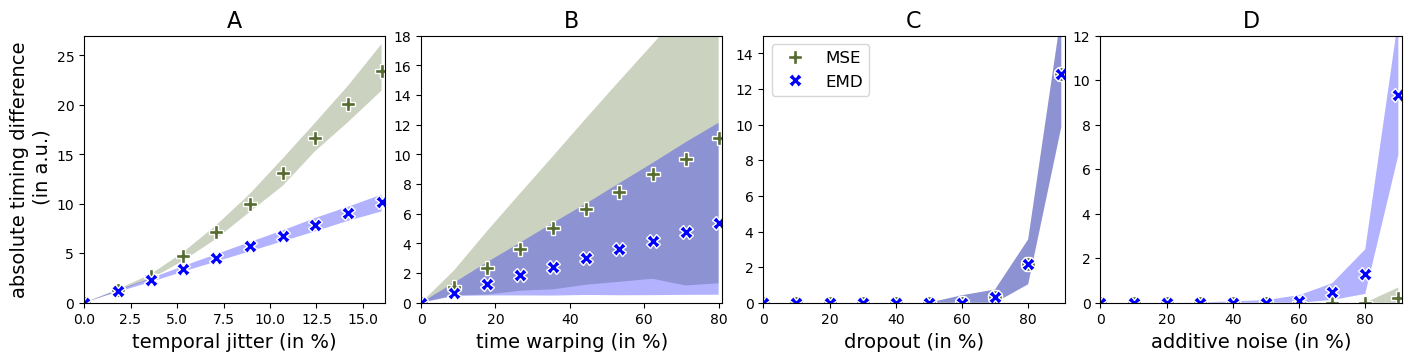

In [11]:
import matplotlib.pyplot as plt
from wassa_plots import plot_results_std

coefs = [coefs_jitter, coefs_warping, coefs_dropout, coefs_additive]
results = [results_jitter, results_warping, results_dropout, results_additive]
xlabels = ['temporal jitter (in %)', 'time warping (in %)', 'dropout (in %)', 'additive noise (in %)']
name_methods = ['MSE','EMD']
markers = ['P','X']
colors = ['darkolivegreen','blue','purple','orangered']
quantile = True

fig, ax = plt.subplots(1,4, figsize=(14,3.5),constrained_layout = True)
for i in range(len(xlabels)):
    for m in range(len(name_methods)):
        ymin, ymax = 0, 27
        xmin, xmax = 0, 91
        do_legend, log_x, log_y = False, False, False
        ylabel = ''
        if i==3:
            ymin, ymax = 0, 12
        if i==2:
            ymin, ymax = 0, 15
            do_legend = True

        elif i==1:
            xmin, xmax = 0, 81
            ymin, ymax = 0, 18
        elif i==0:
            xmin, xmax = 0, 16.2
            ylabel = 'absolute timing difference\n (in a.u.)'
        ax[i] = plot_results_std(ax[i],results[i][:,m],coefs[i],training_metrics+synthetic_metrics,xlabels[i],'mean time diff',name_methods[m],colors[m],ymax=ymax,ymin=ymin,xmax=xmax,xmin=xmin,ylabel=ylabel,do_legend=do_legend,log_x=log_x,log_y=log_y,quantile=quantile,marker=markers[m])
letters = ['A','B','C','D']
for ind, title in enumerate(letters):
    ax[ind].set_title(title, fontsize = 16);

In [13]:
#fig.tight_layout()
fig.savefig('../figures/results_noise.pdf', bbox_inches = 'tight')